# Percent of subclonal SVs per hotspot event (Figure 5B)

In [45]:
# Load libraries
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Define parameters
CLONAL_CCF_THRESHOLD = 0.90     # CCF >= this -> counted as clonal
SUBCLONAL_CCF_THRESHOLD = 0.90  # CCF < this -> counted as subclonal
MIN_SVS_PER_SAMPLE = 3          # minimum non-NaN CCF SVs required to keep a sample/event

HOTSPOT_ORDER = ["TP53", "MYC", "CCND3", "CCNE1", "CDK4-MDM2"]
DEFAULT_LABEL = "cSV"  # label for clustered SVs that don't overlap any defined hotspot

# Samples excluded because of unreliable read length distribution
SAMPLES_TO_EXCLUDE = ["SJOS030101_D2", "SJOS040149_R1"]

## Helper Functions

In [ ]:
# Chromosome / ID helpers
def standardize_chrom(series):
    """Strip a leading 'chr' prefix and cast to string for safe comparison."""
    return series.astype(str).str.replace("^chr", "", regex=True)


def extract_tumor_id(sample_name):
    """Extract a canonical tumor ID from a paired sample name."""
    sample_name = str(sample_name)
    if "TARGET" in sample_name:
        return "-".join(sample_name.split("-")[:4])
    return sample_name.split("-")[0]

# er-sample variant processing
def process_variants(structure_df, certainty_df, variant_type, sample, purity):
    """Annotate a cluster-certainty table with CCF and clonality status.
    """
    structure_df = structure_df.copy()
    structure_df["CCF"] = structure_df["proportion"] / purity
    structure_df["Clonality_Status"] = np.where(
        structure_df["CCF"] >= CLONAL_CCF_THRESHOLD, "Early_Clonal", "Subclonal"
    )

    merged_df = certainty_df.merge(
        structure_df[["cluster", "CCF", "Clonality_Status"]],
        left_on="most_likely_assignment",
        right_on="cluster",
        how="left",
    )
    merged_df["Variant_Type"] = variant_type
    merged_df["Sample_ID"] = sample
    return merged_df.drop(columns=["cluster"])


def load_sample_variants(sample_dir, sample, purity):
    """Load and process SV and SNV tables for one sample.
    Uses the post_assign directory when available, otherwise ccube_out.
    Returns an empty list if any required file is missing.
    """
    sample_dir = Path(sample_dir)
    post_assign_dir = sample_dir / "ccube_out" / "post_assign"
    ccube_out_dir = sample_dir / "ccube_out"

    sv_dir = post_assign_dir if post_assign_dir.exists() else ccube_out_dir
    snv_dir = sv_dir / "snvs"

    try:
        sv_structure = pd.read_csv(sv_dir / f"{sample}_subclonal_structure.txt", sep="\t")
        sv_certainty = pd.read_csv(sv_dir / f"{sample}_cluster_certainty.txt", sep="\t")
        snv_structure = pd.read_csv(snv_dir / f"{sample}_subclonal_structure.txt", sep="\t")
        snv_certainty = pd.read_csv(snv_dir / f"{sample}_cluster_certainty.txt", sep="\t")
    except FileNotFoundError as err:
        print(f"  - Missing file for {sample}: {err}")
        return []

    return [
        process_variants(sv_structure, sv_certainty, "SV", sample, purity),
        process_variants(snv_structure, snv_certainty, "SNV", sample, purity),
    ]


def load_terra_targets(terra_table_path):
    """Load the Terra table and resolve which samples have clustering targets."""
    terra_table = pd.read_csv(terra_table_path, sep="\t")

    if "postassign_cluster_results" in terra_table.columns:
        terra_table["target_tar"] = terra_table["postassign_cluster_results"].fillna(
            terra_table["svclone_final_tar"]
        )
    else:
        terra_table["target_tar"] = terra_table["svclone_final_tar"]

    df_terralinks = (
        terra_table[terra_table["target_tar"].notna()]
        .rename(columns={"entity:SV_Clone_Samples_id": "Samples"})
        .copy()
    )
    print(f"Samples with clustering targets: {df_terralinks.shape[0]}")
    return df_terralinks


def build_master_variant_table(df_terralinks, base_dir):
    """Loop over every sample in df_terralinks and build the master SV/SNV table."""
    base_dir = Path(base_dir)
    master_frames = []
    for _, row in df_terralinks.iterrows():
        sample = row["Samples"]
        print(f"Processing {sample}...")
        master_frames.extend(
            load_sample_variants(base_dir / sample, sample, row["purity"])
        )
    final_master_df = pd.concat(master_frames, ignore_index=True)
    print("Master dataframe created successfully.")
    return final_master_df

# Hotspot annotation / matching
def annotate_clustered_svs_with_hotspots(clustered_svs, hotspots, default_label=DEFAULT_LABEL):
    """Label every clustered SV (cSV) event with the hotspot it overlaps.
    Every row is returned, Rows that don't overlap any hotspot get
    `default_label`. Matching regions are extended to the UNION of the cSV span and the
    hotspot span. Extending guarantees the hotspot's full defined span is always covered.
    """
    svs = clustered_svs.copy()
    svs["hotspot_event"] = default_label
    sv_chrom = standardize_chrom(svs["chr"])

    for _, hotspot in hotspots.iterrows():
        h_chrom = str(hotspot["chrom"]).replace("chr", "")
        mask = (
            (sv_chrom == h_chrom)
            & (svs["start"] <= hotspot["end"])
            & (svs["end"] >= hotspot["start"])
            & (svs["hotspot_event"] == default_label)  # first match wins
        )
        if not mask.any():
            continue
        svs.loc[mask, "start"] = np.minimum(svs.loc[mask, "start"], hotspot["start"])
        svs.loc[mask, "end"] = np.maximum(svs.loc[mask, "end"], hotspot["end"])
        svs.loc[mask, "hotspot_event"] = hotspot["event"]

    return svs


def match_svs_to_regions(regions_df, variant_df):
    """Keep SVs with at least one breakend inside a sample-matched region.
    `regions_df` must have columns: Tumor_ID, chr, start, end, hotspot_event
    (optionally event_id). 
    `variant_df` must have Sample_ID, chr1, pos1, chr2, pos2.
    """
    matched = []

    for _, region in regions_df.iterrows():
        target_id = region["Tumor_ID"]
        r_chrom = str(region["chr"]).replace("chr", "")
        r_start, r_end = region["start"], region["end"]

        sample_svs = variant_df[variant_df["Sample_ID"] == target_id]
        if sample_svs.empty:
            continue

        mask = (
            (standardize_chrom(sample_svs["chr1"]) == r_chrom)
            & sample_svs["pos1"].between(r_start, r_end)
        ) | (
            (standardize_chrom(sample_svs["chr2"]) == r_chrom)
            & sample_svs["pos2"].between(r_start, r_end)
        )

        hits = sample_svs.loc[mask].copy()
        if hits.empty:
            continue

        hits["hotspot_event"] = region["hotspot_event"]
        hits["event_id"] = region.get("event_id", "N/A")
        matched.append(hits)

    if matched:
        result = pd.concat(matched).drop_duplicates()
    else:
        result = pd.DataFrame(columns=list(variant_df.columns) + ["hotspot_event", "event_id"])

    print(f"Original SVs:               {len(variant_df)}")
    print(f"SVs inside matched regions: {len(result)}")
    print(f"Unique samples in result:   {result['Sample_ID'].nunique()}")
    return result


def apply_sample_exclusions(df, meta_path, sample_id_col="Sample_ID"):
    """Drop hard-coded low-quality samples and metadata-flagged multi-tumor samples.
    """
    meta = pd.read_csv(meta_path, sep="\t")
    multi_tumor_ids = meta.loc[meta["filter status"] == "multiple-tumor", "Tumor_ID"]

    out = df[~df[sample_id_col].isin(SAMPLES_TO_EXCLUDE)]
    out = out[~out[sample_id_col].isin(multi_tumor_ids)]
    return out

In [ ]:
# Define paths
BASE_DIR = Path("/Users/thorsten/Postdoc/Osteosarcoma_wgs_shreya/Data/SV_Clone/SVClone_Output")
TERRA_TABLE_PATH = Path("../../../SV_Clone/SV_Clone_Samples_id_terra_table.tsv")
CLUSTERED_SV_PATH = Path("../../../SV_Clone/merged_clustered_sv_events.csv")
HOTSPOT_PATH = Path("../../../SV_Clone/hotspot_event_definitions.csv")
METADATA_PATH = Path("../../../metadata/2026_06_08_Metadata_v11.tsv")
FIGURE_PATH = Path("../../Images/Figures/Hotspots_percentage_of_Subclonal_SVs_only_cSV_samples.pdf")

## 1. Load Terra table and build master variant table (shared)

In [49]:
# We worked in Terra and therefore loaded the samples using the master table with links of the SVClone analysis to the Google Cloud bucket. 
# If you work locally, you need to generate a table that tells the path to the output files of SVClone on your local computer and use it to generate a master file with all SVs and SNVs and their corresponding SVClone outputs. 
df_terralinks = load_terra_targets(TERRA_TABLE_PATH)
final_master_df = build_master_variant_table(df_terralinks, BASE_DIR)

Samples with clustering targets: 193
Processing 09T02...
Processing 09T03...
Processing 10T03...
Processing 13T02...
Processing 17_439_00067_T2...
Processing 21T01...
Processing 24T02...
Processing 39T01...
Processing 39T03...
Processing 41T01...
Processing 41T02...
Processing 41T03...
Processing CCG1106_005_T1...
Processing CCG1106_074_T1...
Processing CCG1106_075_T1...
Processing CCG1106_084_T1...
Processing CCG1106_086_T1...
Processing SA541864...
Processing SA541866...
Processing SA541868...
Processing SA541870...
Processing SA541872...
Processing SA541874...
Processing SA541876...
Processing SA541878...
Processing SA541880...
Processing SA541882...
Processing SA541884...
Processing SA541886...
Processing SA541888...
Processing SA541890...
Processing SA541892...
Processing SA541894...
Processing SA541896...
Processing SA541898...
Processing SA541900...
Processing SA541902...
Processing SA541904...
Processing SA541906...
Processing SA541910...
Processing SA541912...
Processing SA541

In [50]:
# Example how the master file looks
final_master_df

,chr1,pos1,dir1,chr2,pos2,dir2,most_likely_assignment,average_proportion1,average_proportion2,CCF,Clonality_Status,Variant_Type,Sample_ID,chr,pos,average_proportion
0,chr1,25148899.0,+,chr1,25252736.0,-,2,0.562890,0.588950,1.000000,Early_Clonal,SV,09T02,NaN,NaN,NaN
1,chr1,160827718.0,-,chr1,160890810.0,+,2,0.696349,0.720421,1.000000,Early_Clonal,SV,09T02,NaN,NaN,NaN
2,chr1,246260290.0,-,chr19,6750722.0,-,2,1.006372,0.822695,1.000000,Early_Clonal,SV,09T02,NaN,NaN,NaN
3,chr1,246260359.0,-,chr17,44320867.0,-,2,1.139370,0.946784,1.000000,Early_Clonal,SV,09T02,NaN,NaN,NaN
4,chr1,246262799.0,+,chr21,26839044.0,+,2,1.080097,0.756052,1.000000,Early_Clonal,SV,09T02,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2127550,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,0.362006,Subclonal,SNV,WGS_12_7,chr22,50406276.0,0.221197
2127551,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,0.362006,Subclonal,SNV,WGS_12_7,chr22,50434318.0,0.227157
2127552,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,0.362006,Subclonal,SNV,WGS_12_7,chr22,50489000.0,0.260879
2127553,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,0.362006,Subclonal,SNV,WGS_12_7,chr22,50681200.0,0.326847


## 2. Load and annotate clustered SV regions with hotspot events

In [51]:
# Load and makes sure both files have same chromosome annnotation format
# Clustered SV region file is a file that list all regions with clustered SV occurence from previous analyses (but not yet if it is associated with a hotspot region)
# Hotspot regions file defines hotspot regions and give them a name. 
clustered_sv_regions = pd.read_csv(CLUSTERED_SV_PATH)
hotspot_regions = pd.read_csv(HOTSPOT_PATH)
hotspot_regions["chrom"] = hotspot_regions["chrom"].astype(str).str.replace("^chr", "", regex=True)
# Annotates if a clustered SV lies in a hotspot regions and in which. Also extends mean hotspot regions in samples where clustered regions is larger than in hotspot regions (see function)
annotated_csvs = annotate_clustered_svs_with_hotspots(clustered_sv_regions, hotspot_regions)
annotated_csvs["Tumor_ID"] = annotated_csvs["sample"].apply(extract_tumor_id)

In [52]:
# Filter out all SVs that are in non-clustered regions
hotspot_csvs_only = annotated_csvs[annotated_csvs["hotspot_event"] != DEFAULT_LABEL]

## 3. Match breakpoint-level SVs to those cSV-overlapping hotspot regions

In [53]:
# Filter for SV only in master file
sv_df = final_master_df[final_master_df["Variant_Type"] == "SV"]
# checks if SVs are in hotspot clustered regions 
clonality_hotspot_df = match_svs_to_regions(hotspot_csvs_only, sv_df)

Original SVs:               34882
SVs inside matched regions: 5524
Unique samples in result:   111


## 4. Exclusions of samples that cannot be analyzed by SVClone 

SVClone needs reliable read length, otherwise the estimation of CCF gets unreliable. Samples with a large deviation of read lengths or bimodal distribution of read lengths were excluded (see also Methods)

In [54]:
clonality_hotspot_df = apply_sample_exclusions(clonality_hotspot_df, METADATA_PATH)

## SPECIAL FILTER STEP

Per-sample, per-event % subclonal, requiring at least `MIN_SVS_PER_SAMPLE` non-NaN CCF values. Change `MIN_SVS_PER_SAMPLE` in the shared-functions block above if you want to adapt it. 

In [55]:
records = []
for event in HOTSPOT_ORDER:
    subset = clonality_hotspot_df[clonality_hotspot_df["hotspot_event"] == event]
    for sample in subset["Sample_ID"].unique():
        ccf = subset.loc[subset["Sample_ID"] == sample, "CCF"].dropna()
        if len(ccf) < MIN_SVS_PER_SAMPLE:
            continue
        records.append({
            "event": event,
            "sample": sample,
            "pct_subclonal": float(np.mean(ccf < SUBCLONAL_CCF_THRESHOLD) * 100),
            "n_svs": len(ccf),
        })

df_sub = pd.DataFrame(records)
df_sub.groupby("event")["sample"].nunique()

event
CCND3        26
CCNE1        18
CDK4-MDM2    19
MYC          28
TP53         35
Name: sample, dtype: int64

## 5. Plot

/var/folders/54/_6vs7vnn4433pfg0vbsbtjgw0000gn/T/ipykernel_42030/2623908443.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


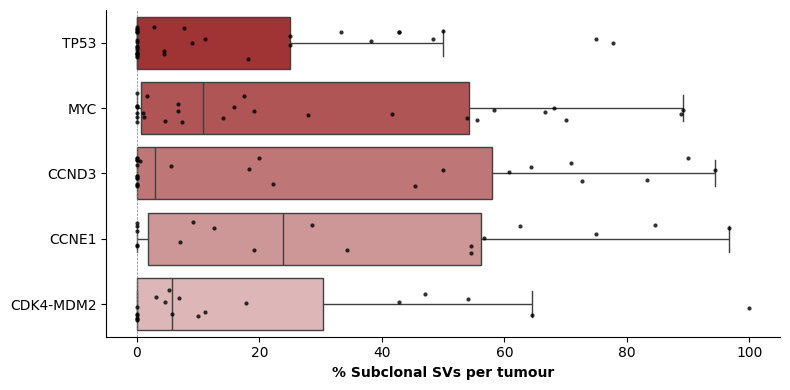

In [56]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(
    data=df_sub, y="event", x="pct_subclonal", order=HOTSPOT_ORDER,
    palette="blend:#b22222ff,#e3b1b1ff", fliersize=0, ax=ax,
)
sns.stripplot(
    data=df_sub, y="event", x="pct_subclonal", order=HOTSPOT_ORDER,
    color="black", alpha=0.8, size=3, jitter=0.25, ax=ax,
)
ax.axvline(0, color="grey", lw=0.5, linestyle="--")
ax.set_xlabel("% Subclonal SVs per tumour", fontweight="bold")
ax.set_ylabel("")
ax.set_xlim(-5, 105)
sns.despine()
fig.tight_layout()

FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURE_PATH, dpi=300, bbox_inches="tight")
plt.show()

In [58]:
n_total = len(df_sub)
n_exclusively_clonal = (df_sub["pct_subclonal"] == 0).sum()
n_with_subclonal = (df_sub["pct_subclonal"] > 0).sum()

pct_exclusively_clonal = n_exclusively_clonal / n_total * 100
pct_with_subclonal = n_with_subclonal / n_total * 100

print(f"Total hotspot events (sample x hotspot): {n_total}")
print(f"Exclusively clonal (0% subclonal):        {n_exclusively_clonal} ({pct_exclusively_clonal:.1f}%)")
print(f"Contain subclonal SVs (>0% subclonal):    {n_with_subclonal} ({pct_with_subclonal:.1f}%)")

Total hotspot events (sample x hotspot): 126
Exclusively clonal (0% subclonal):        48 (38.1%)
Contain subclonal SVs (>0% subclonal):    78 (61.9%)
